In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [295]:
coords = [[1.6, 0.0], [1.7, 0.1], [1.4, 0.5]] #1st: multistable     // 2nd: unistable synchronized
N = 1

data = dict()
data["coordinates"] = coords[2]

phi_shift = np.arange(0, 2*np.pi, 0.1*np.pi)

data["control"] = [None] * len(phi_shift)
data["state"] = [None] * len(phi_shift)
data["init_state"] = None
data["state_uncontrolled"] = None
data["target"] = [None] * len(phi_shift)

In [296]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    #model.params.a_exc = 1.  # excitatory gain
    #model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 3.0  # excitatory firing threshold
    model.params.mu_inh = 3.0  # inhibitory firing threshold

def plot_control(c, s, target, dur, dt, filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    ax[0].plot(time_array, s[0,0,:])
    ax[0].plot(time_array, target[0,0,:], linestyle="dashed", color="gray")
    ax[1].plot(time_array, c[0,0,:])

    ax[0].set_xlim(0, dur)
    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, i, mc):
    d["control"][i] = mc.control.copy()
    d["state"][i] = mc.get_xs()

def dump_data():
    with open(os.path.join(datadir, 'wc_phase_shift.pickle'), 'wb') as f:
        pickle.dump(data, f)

def get_period(x, dt):
    period = []
    peaks = scipy.signal.find_peaks(x, height=0.4)[0]
    for p in range(len(peaks)-1):
        period.append((peaks[p+1]-peaks[p])*dt)
    return np.mean(period)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,1001,10)
dt = 0.1

control_int = (None, None)

1.4 0.5


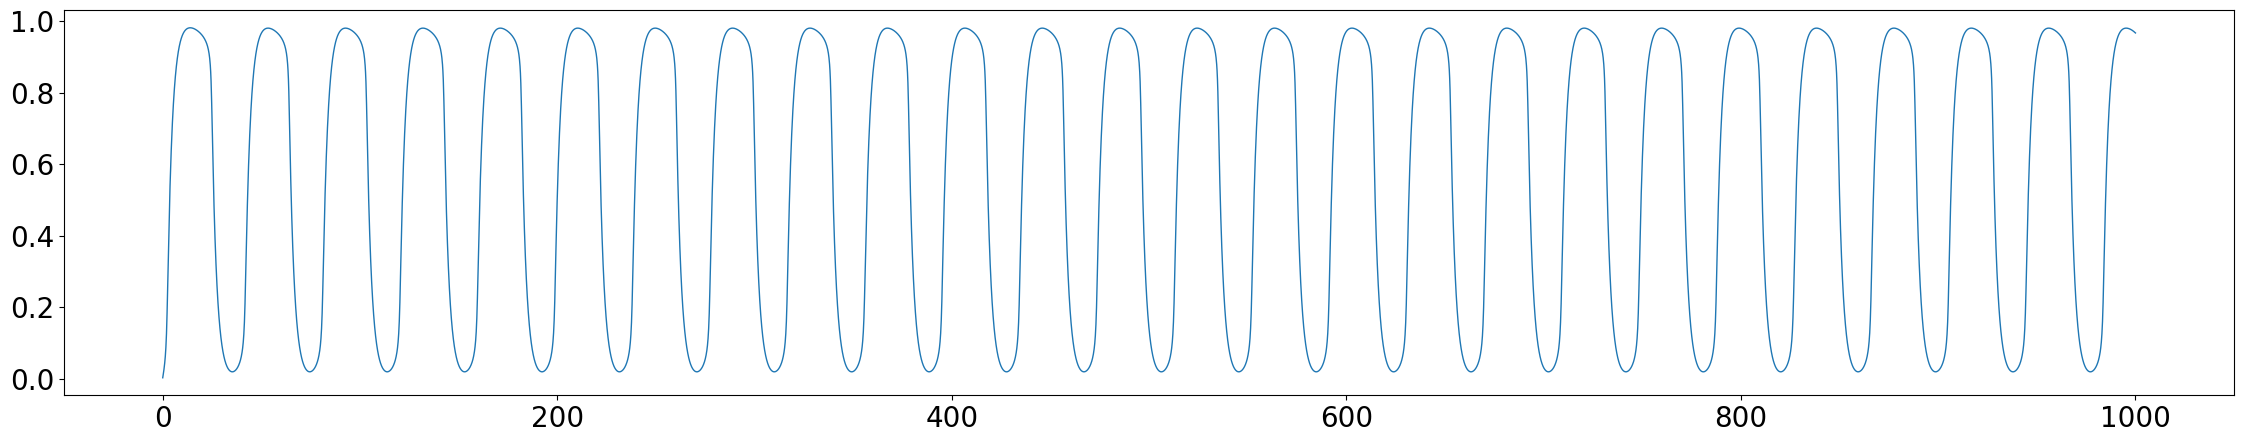

Period:  39.248000000000005
1.4 0.8


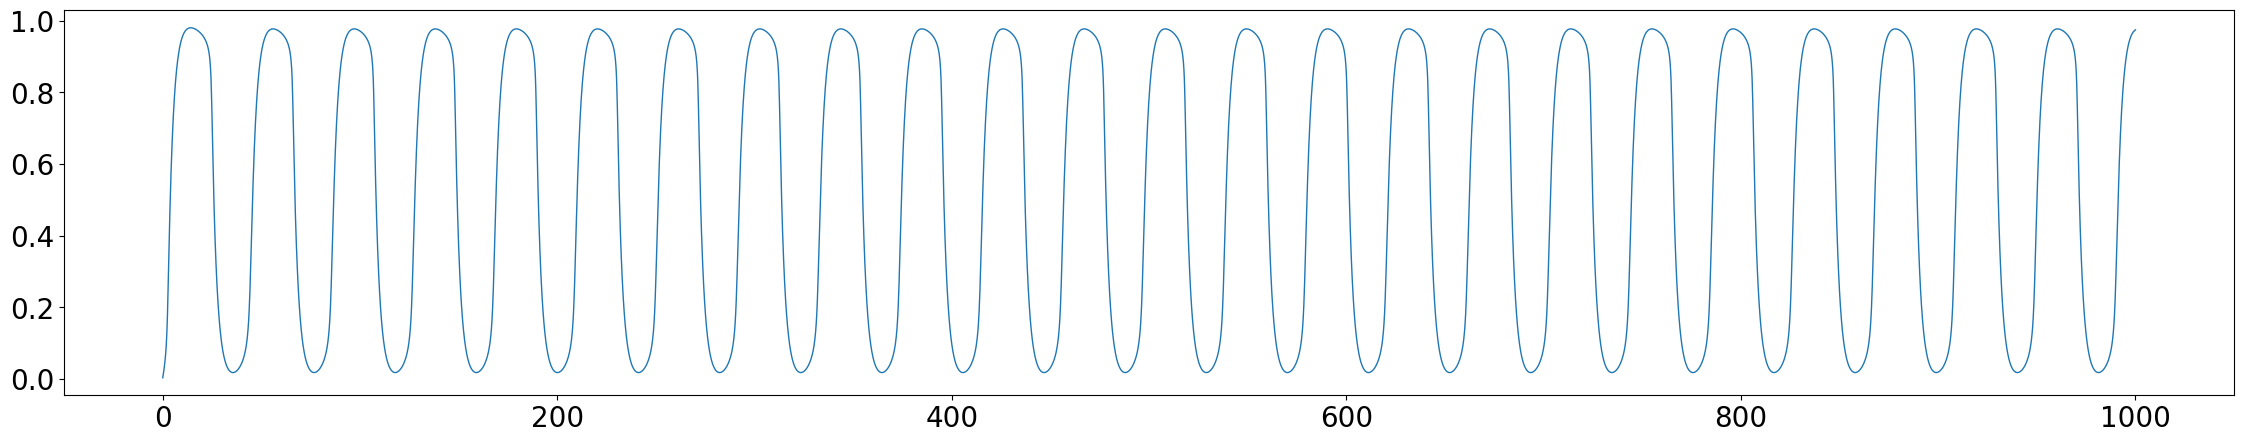

Period:  41.13913043478262
1.4 1.1


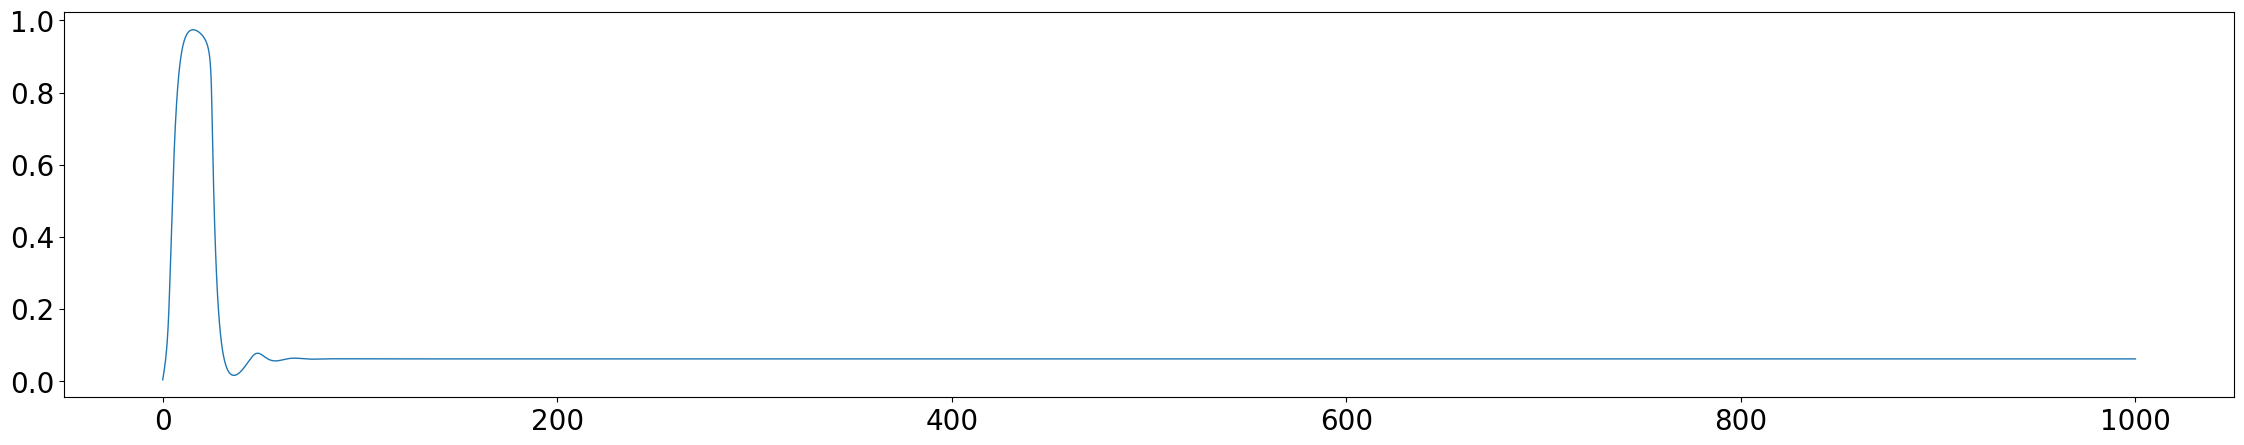

Period:  nan
1.4 1.4000000000000001


/home/lena/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lena/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


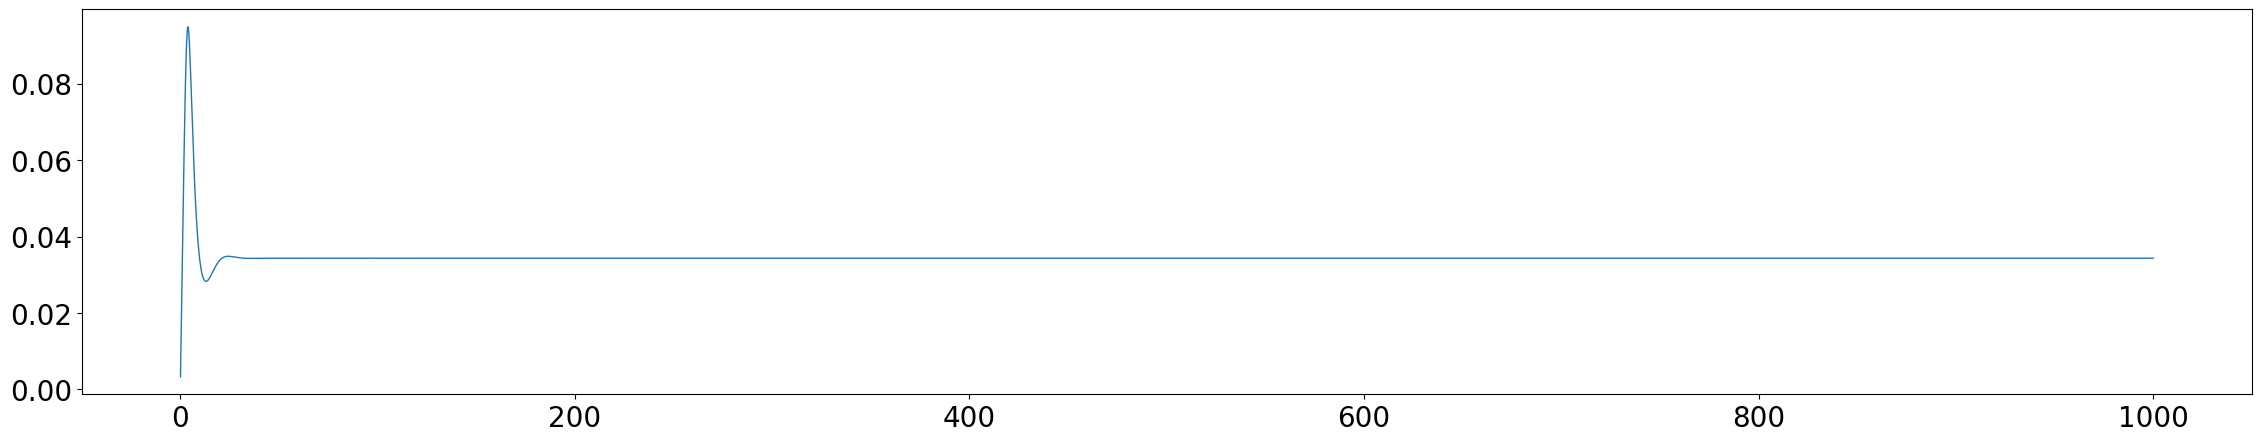

Period:  nan
1.5999999999999999 0.5


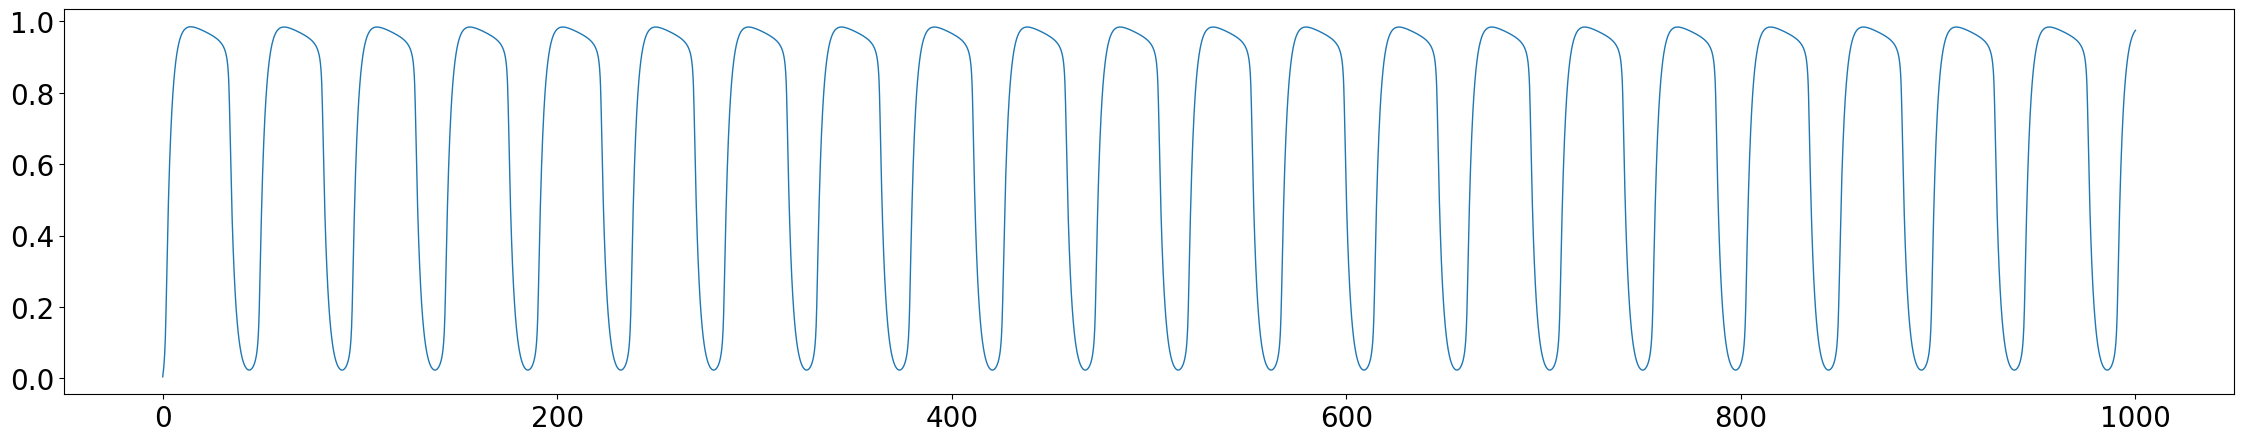

Period:  47.10000000000001
1.5999999999999999 0.8


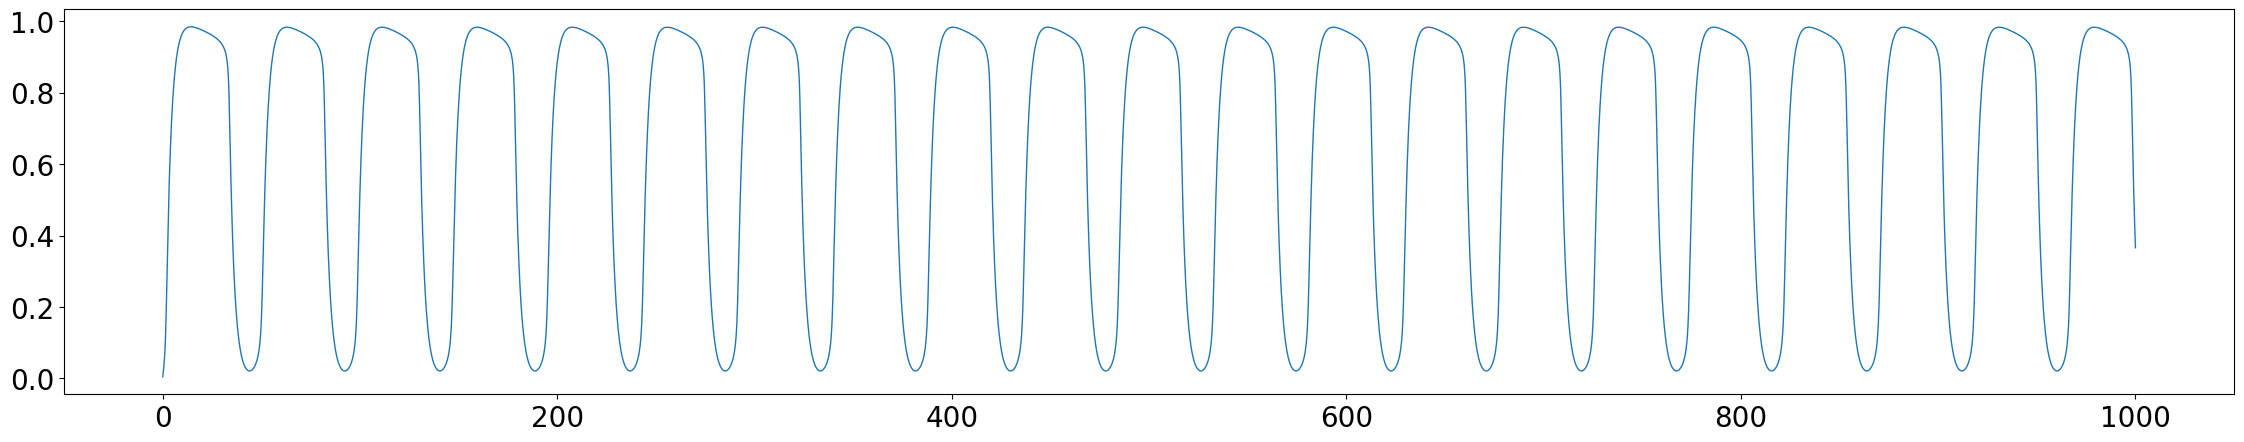

Period:  48.23500000000001
1.5999999999999999 1.1


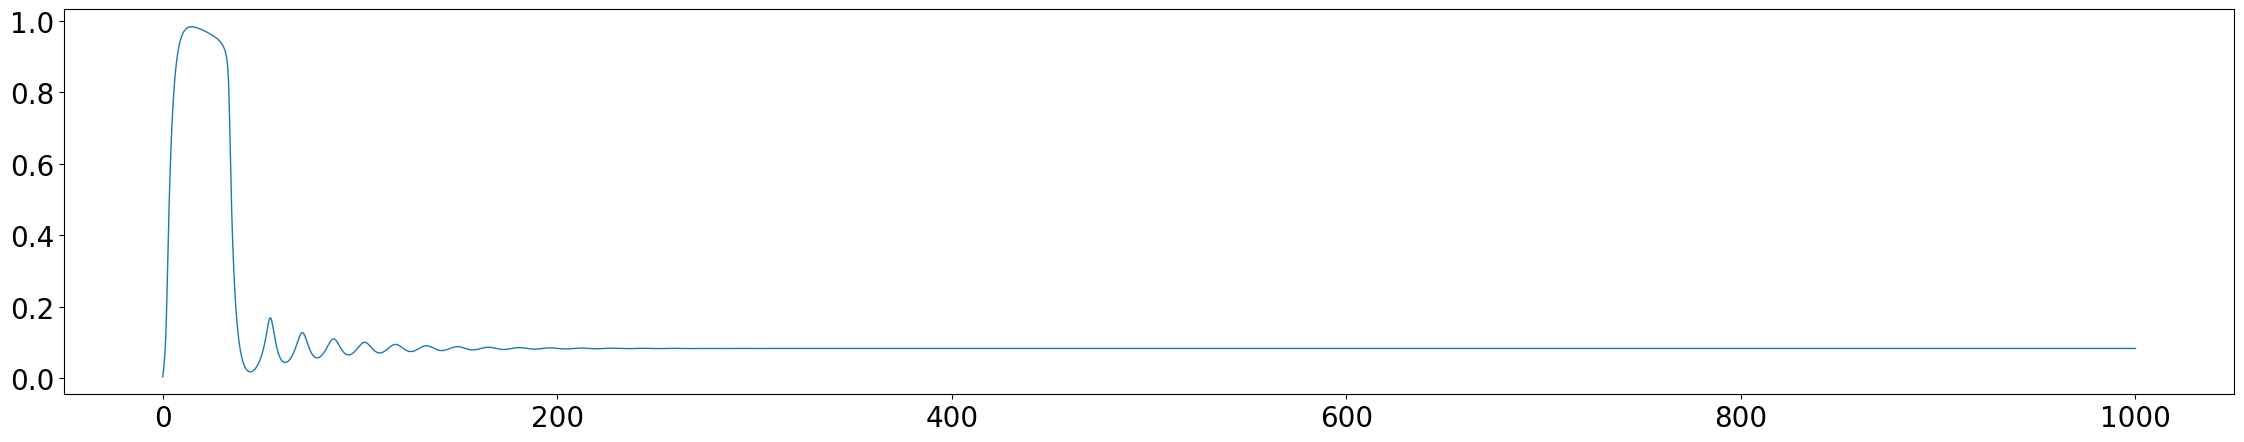

Period:  nan
1.5999999999999999 1.4000000000000001


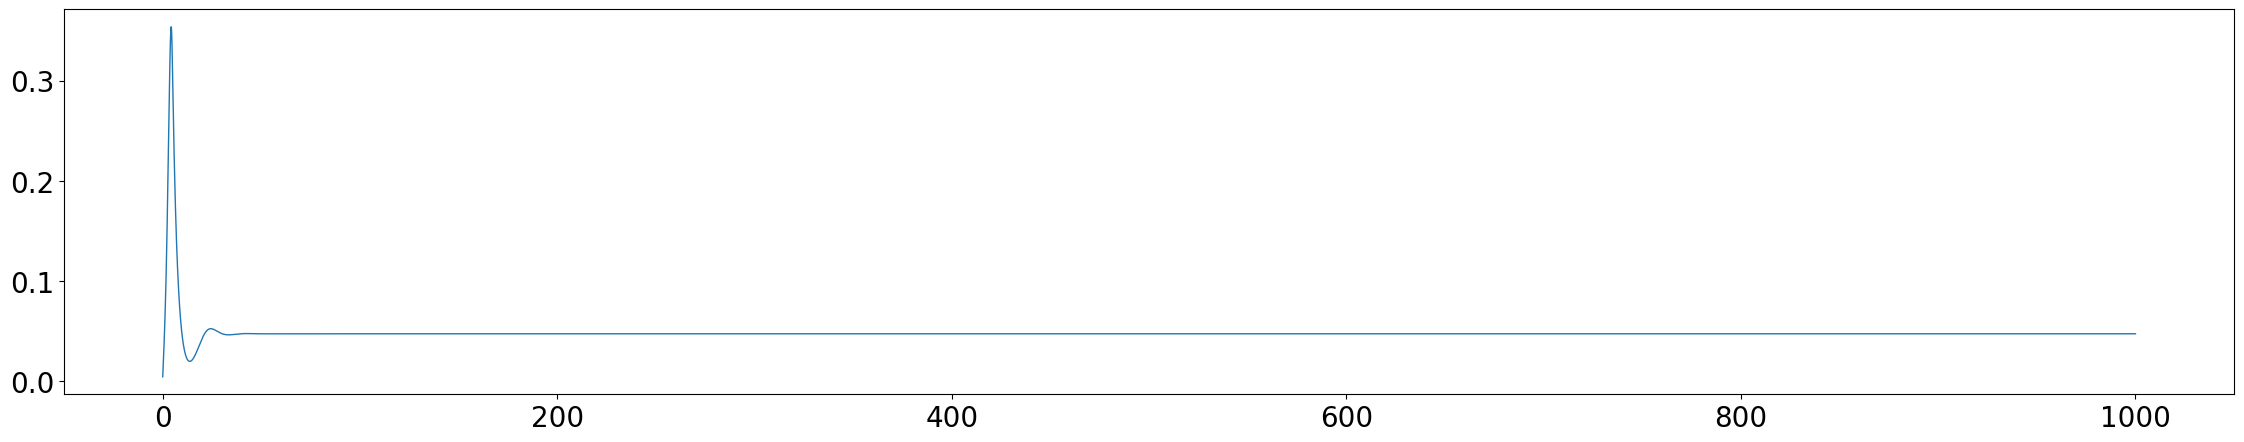

Period:  nan
1.7999999999999998 0.5


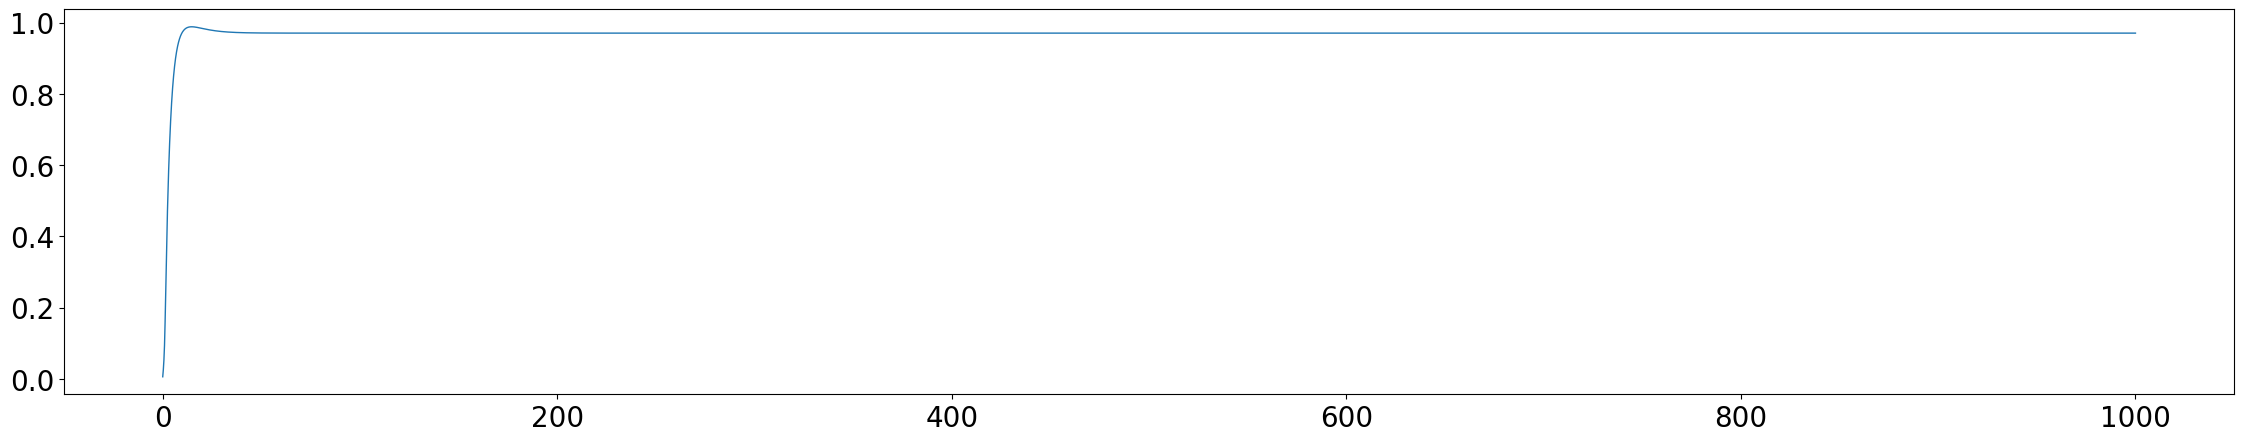

Period:  nan
1.7999999999999998 0.8


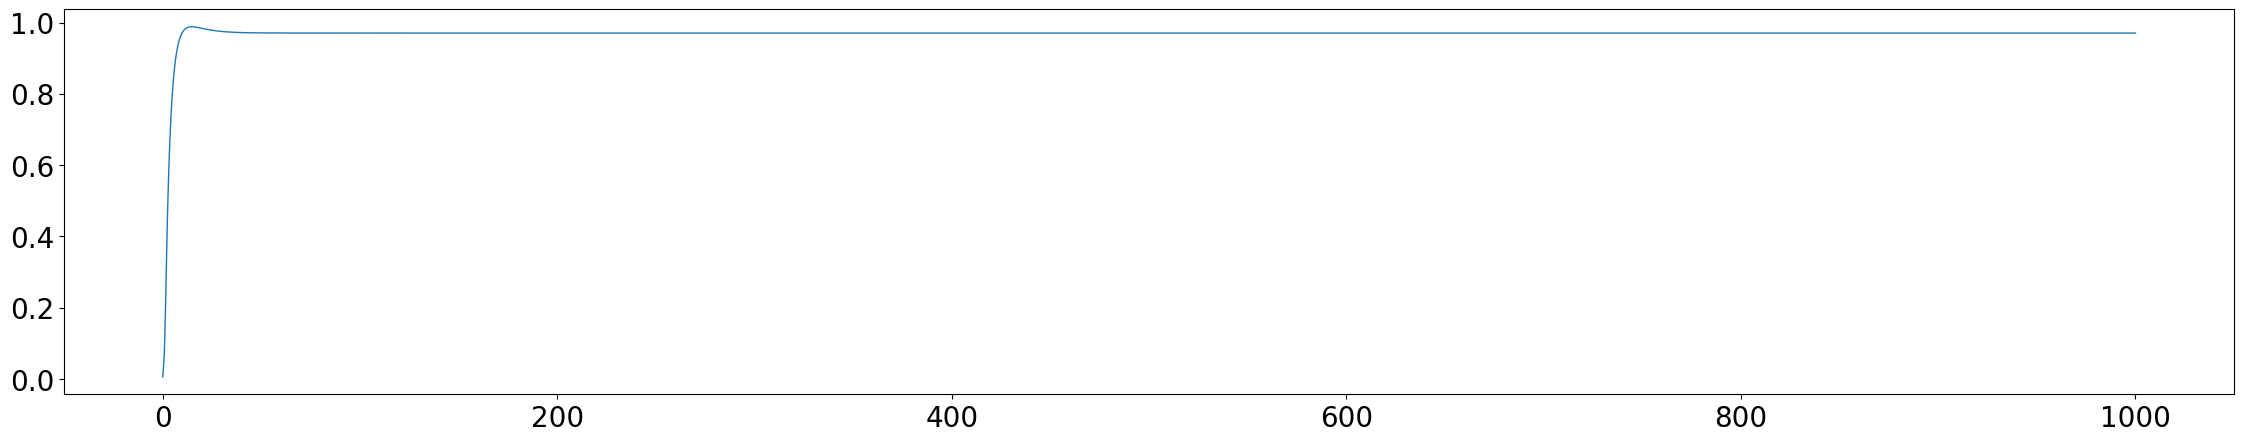

Period:  nan
1.7999999999999998 1.1


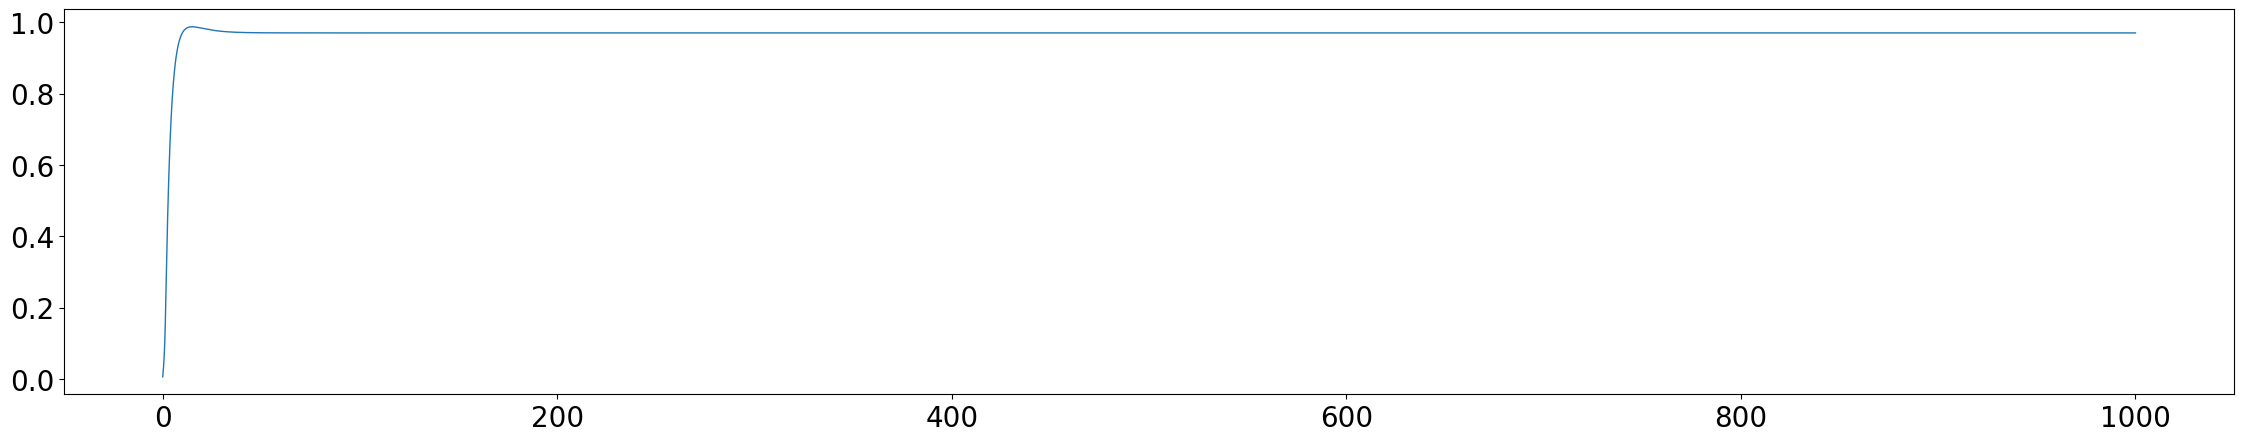

Period:  nan
1.7999999999999998 1.4000000000000001


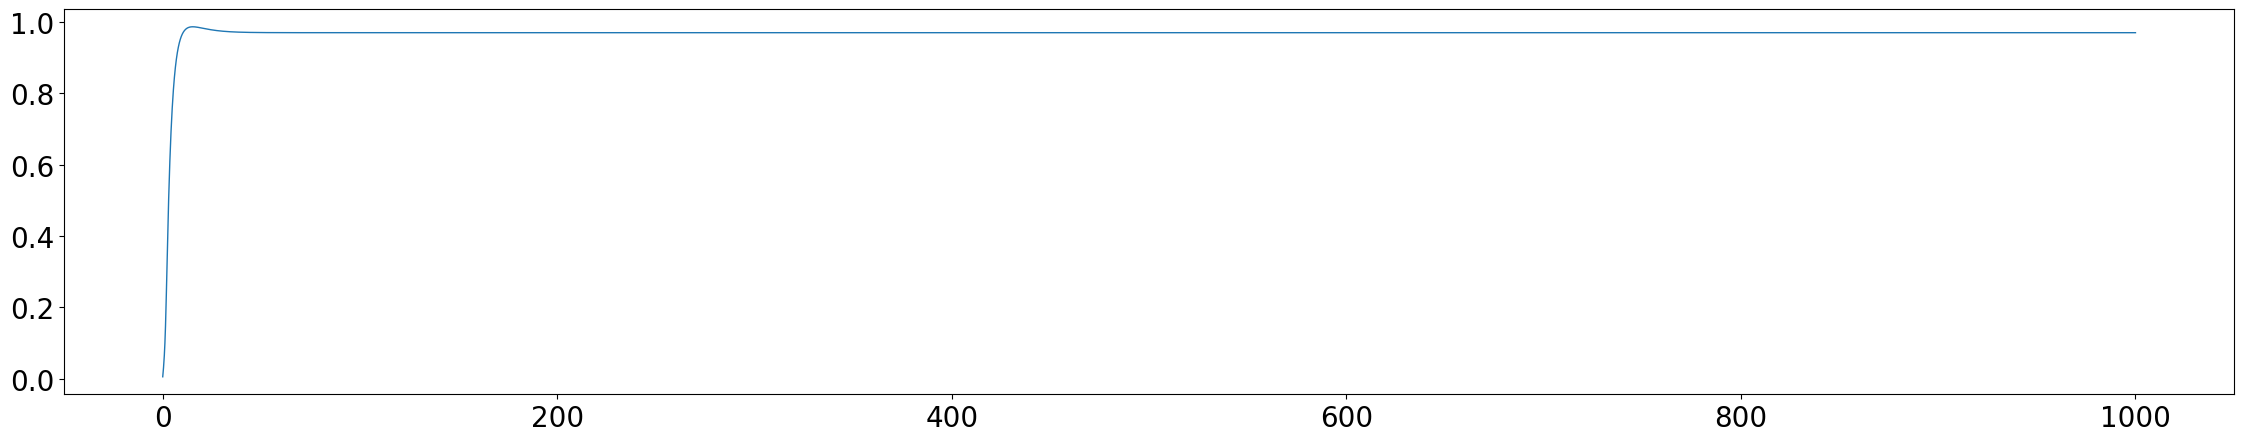

Period:  nan
1.9999999999999998 0.5


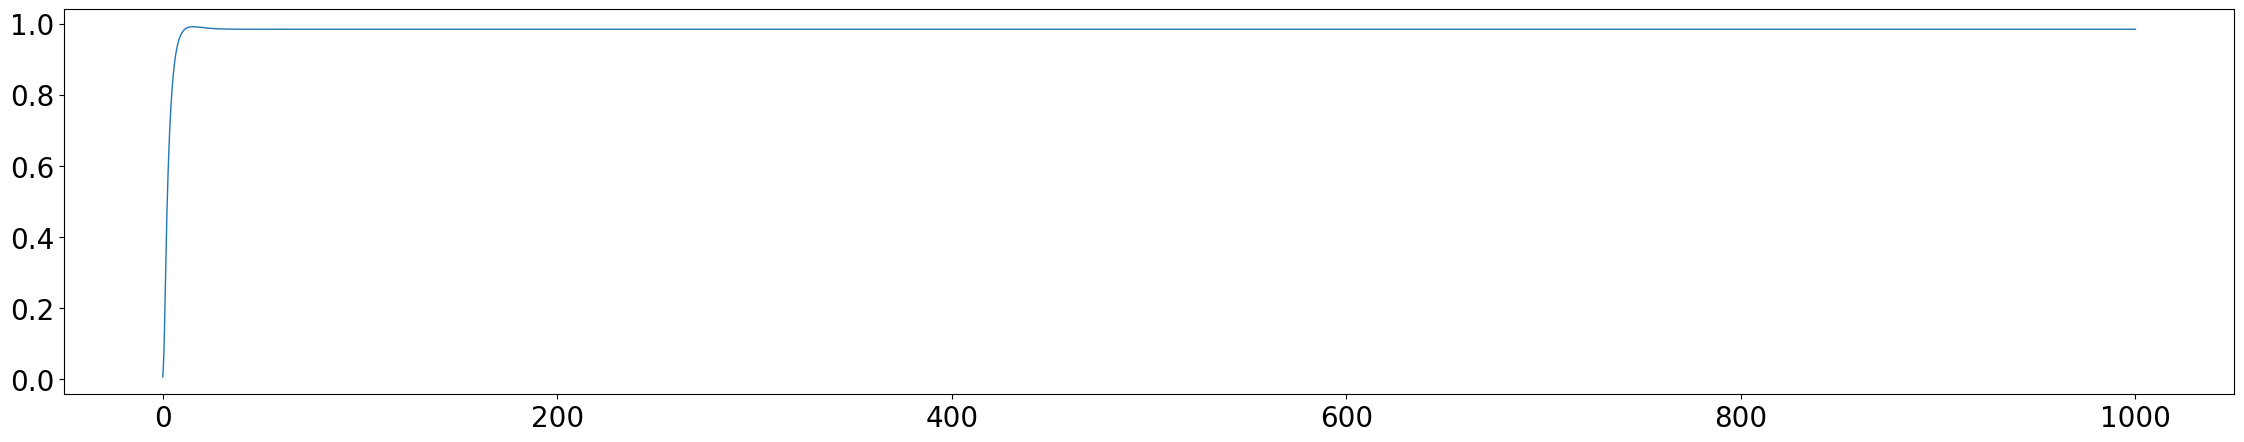

Period:  nan
1.9999999999999998 0.8


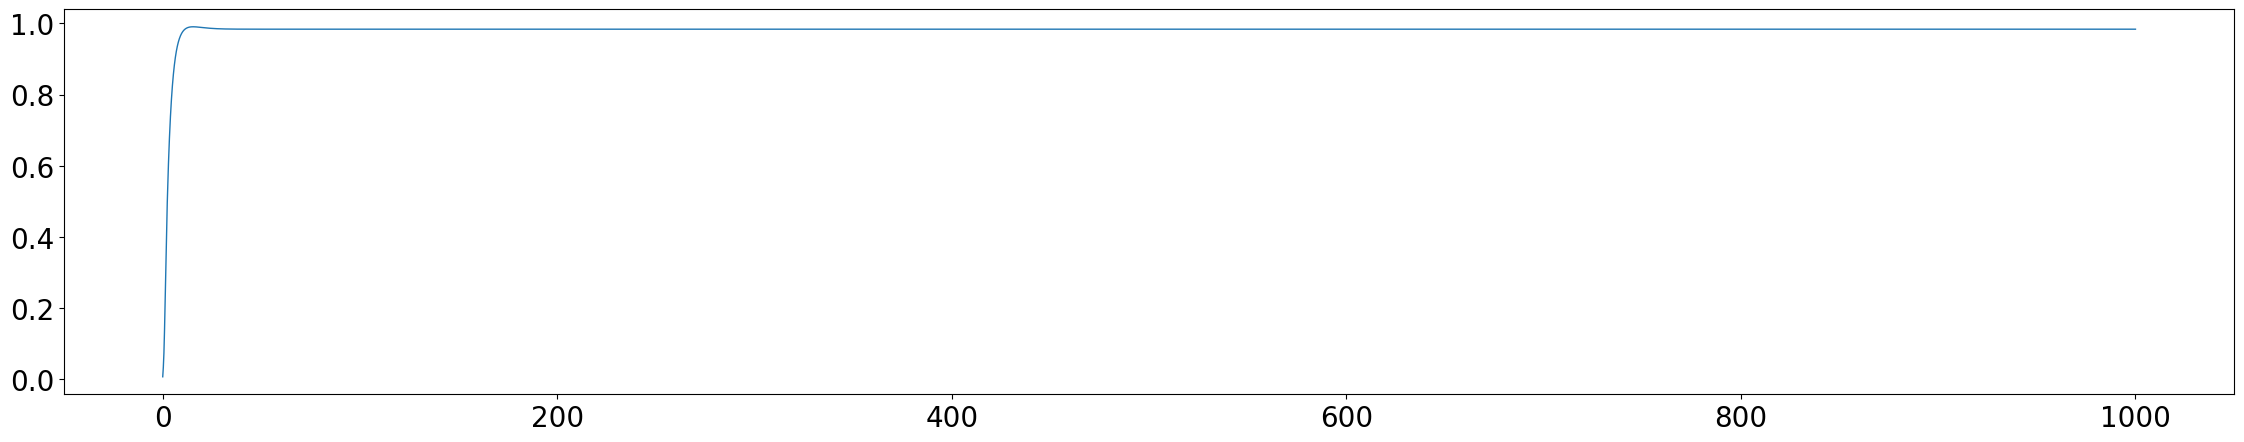

Period:  nan
1.9999999999999998 1.1


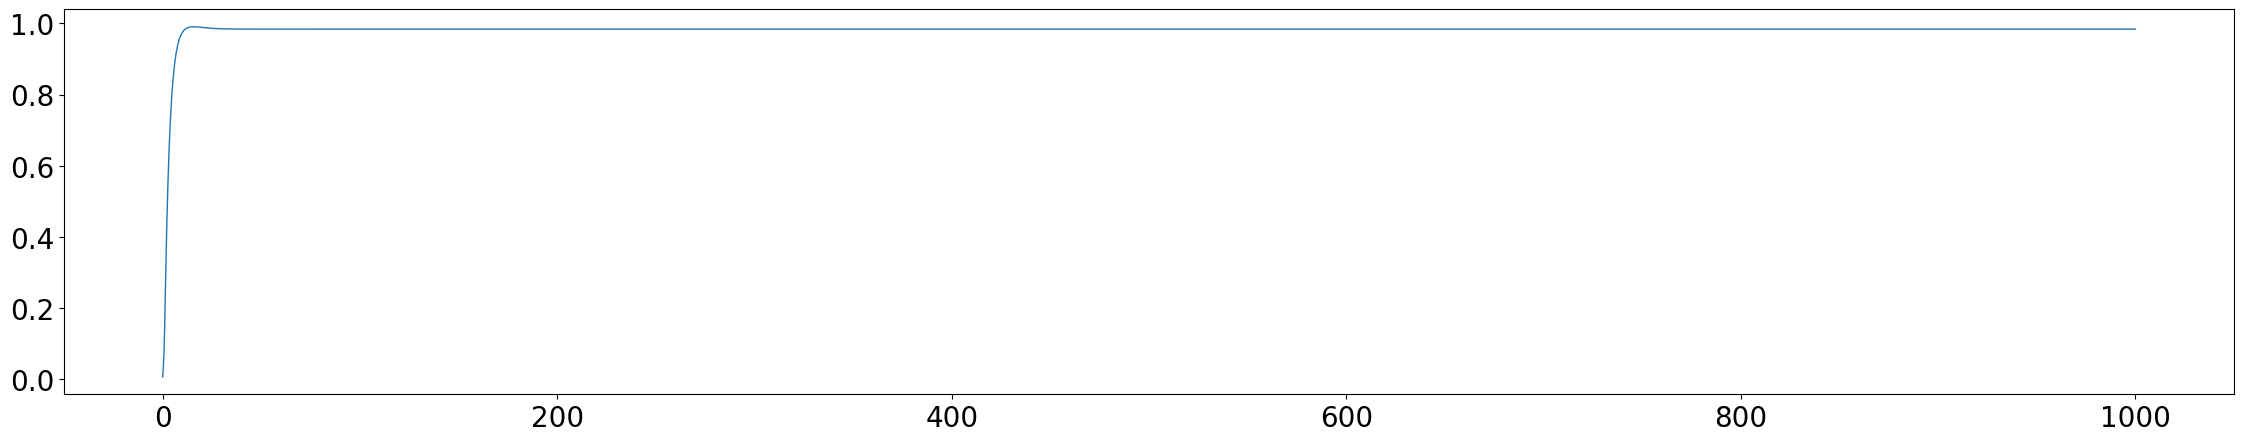

Period:  nan
1.9999999999999998 1.4000000000000001


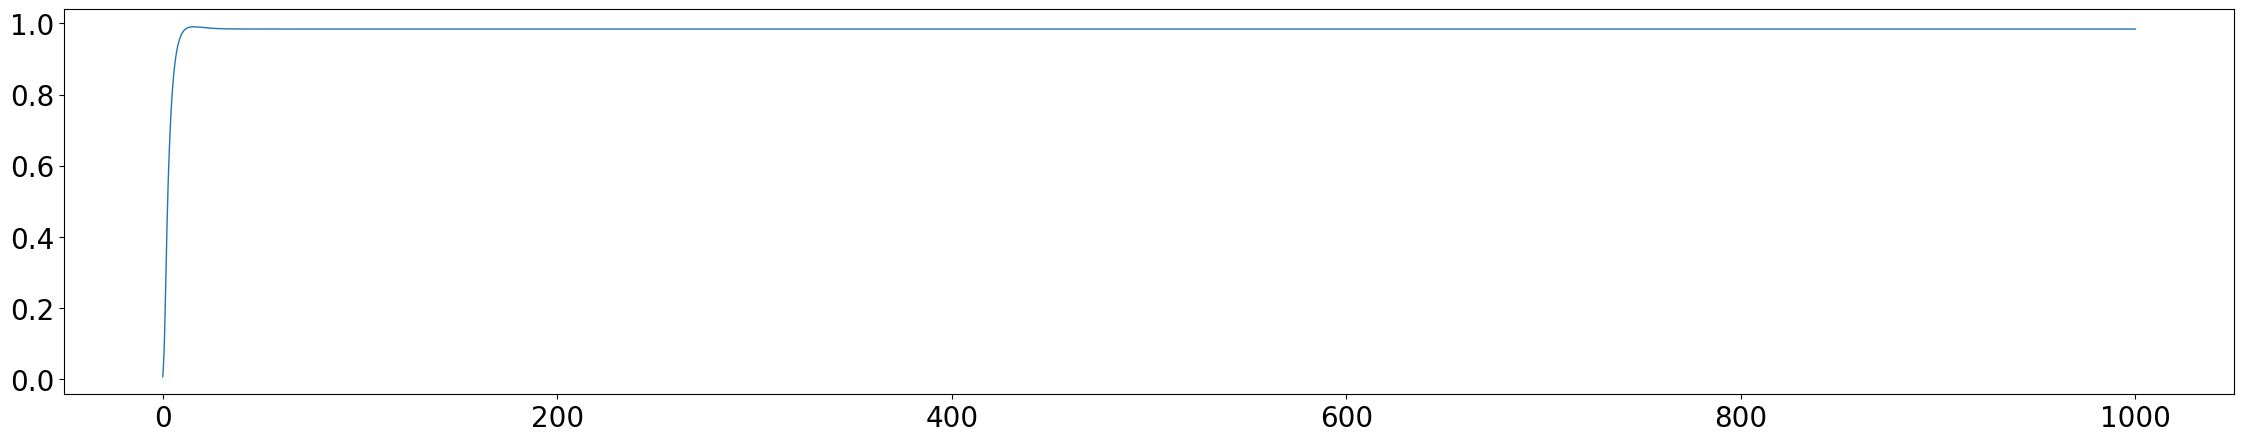

Period:  nan
2.1999999999999997 0.5


KeyboardInterrupt: 

In [297]:
model = WCModel()
testd = 1000.
dt = model.params.dt
model.params.duration = testd
model.params.exc_init = [[0]]
model.params.inh_init = [[0]]
setparams(model)

for eext in np.arange(1.40, 2.5, 0.2):
    for iext in np.arange(0.5, 1.6, 0.3):
        print(eext, iext)
        model.params.exc_ext_baseline = eext#data["coordinates"][0]
        model.params.inh_ext_baseline = iext#data["coordinates"][1]
        model.run()

        plt.figure(figsize=(28,5))

        plt.plot(model.t, model.exc[0,:], linewidth=1)
        plt.show()

        period = get_period(model.exc[0,-10000:], dt)
        print("Period: ", period)

data["init_state"] = [[[model.exc[0,-1]]], [[model.inh[0,-1]]]]

testd = 3000.
model.params.duration = testd
model.run()

duration = 600

for pi, phi in enumerate(phi_shift):
    shift = int(phi/(2*np.pi) * period / dt)
    data["target"][pi] = np.zeros((1, 2, int(duration/dt)+1))
    data["target"][pi][0,0,:] = model.exc[0,10000+shift-1:10000+shift+int(duration/dt)]

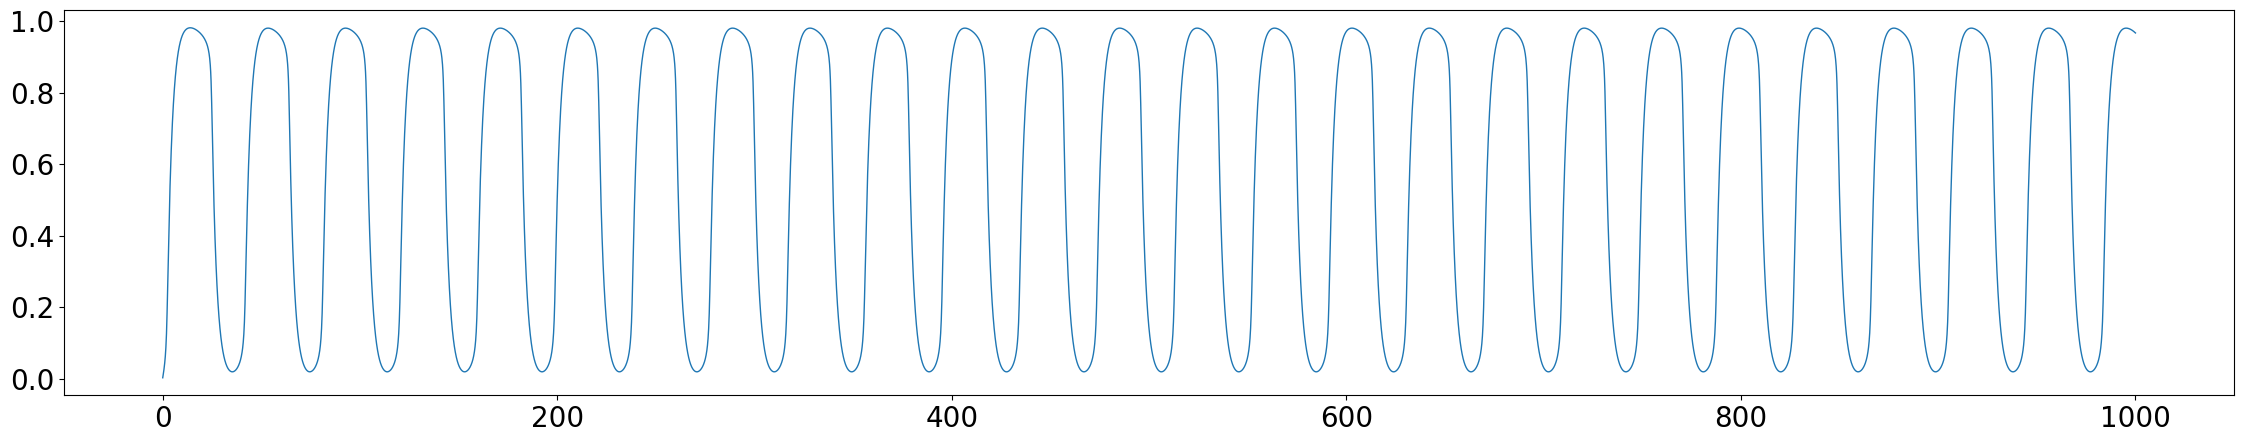

Period:  39.248000000000005


In [298]:
model = WCModel()
testd = 1000.
dt = model.params.dt
model.params.duration = testd
model.params.exc_init = [[0]]
model.params.inh_init = [[0]]
setparams(model)


model.params.exc_ext_baseline = data["coordinates"][0]
model.params.inh_ext_baseline = data["coordinates"][1]
model.run()

plt.figure(figsize=(28,5))

plt.plot(model.t, model.exc[0,:], linewidth=1)
plt.show()

period = get_period(model.exc[0,-10000:], dt)
print("Period: ", period)

data["init_state"] = [[[model.exc[0,-1]]], [[model.inh[0,-1]]]]

testd = 3000.
model.params.duration = testd
model.run()

duration = 450

for pi, phi in enumerate(phi_shift):
    shift = int(phi/(2*np.pi) * period / dt)
    data["target"][pi] = np.zeros((1, 2, int(duration/dt)+1))
    data["target"][pi][0,0,:] = model.exc[0,10000+shift-1:10000+shift+int(duration/dt)]

In [6]:
with open(os.path.join(datadir, 'wc_phase_shift.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data = data_read

In [299]:
it = 10

for pi, phi in enumerate(phi_shift):
    print("------------------------------------------------------------ phi = ", phi)

    if pi in [0]: continue
    if pi == 5: break

    model = WCModel()

    model.params.exc_init = data["init_state"][0]
    model.params.inh_init = data["init_state"][1]
    model.params.seed = 0
    setparams(model)

    model.params["exc_ext_baseline"] =  data["coordinates"][0]
    model.params["inh_ext_baseline"] =  data["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, data["target"][pi], print_array=pr, cost_interval=(None, None), control_interval=control_int, cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 1e0
    model_controlled.weights["w_2"] = 1.

    model_controlled.maximum_control_strength = max_cntrl

    # find initial signal
    model_controlled.channelwise_optimization = True
    model_controlled.step = 1e-1
    model_controlled.optimize(1)

    model_controlled.cost_interval = (int(2*duration/(3*dt)), None)
    #model_controlled.control_interval = (0, 4000)

    get_results(data, pi, model_controlled)
    dump_data()

    for j in range(1):
        model_controlled.grad_method = 0

        for k in range(-8, 8, 1):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            get_results(data, pi, model_controlled)
            dump_data()
    
    plot_control(model_controlled.control, model_controlled.get_xs(), data["target"][pi], duration, dt, filename=None, title=None)

------------------------------------------------------------ phi =  0.0
------------------------------------------------------------ phi =  0.3141592653589793
Optimal control with target time series
Compute control for a deterministic system
Cost in iteration 0: 5.172040607292623


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m('wrong tuple length for model_params: ', 'expected 12, got 13')[0m
[0m[1mDuring: typing of exhaust iter at /home/lena/Promotion/neurolib/neurolib/models/wc/timeIntegration.py (500)[0m
[1m
File "neurolib/models/wc/timeIntegration.py", line 500:[0m
[1mdef compute_hx_nw(
    <source elided>
        tau_exc,
[1m        tau_inh,
[0m        [1m^[0m[0m


------------------------------------------------------------ phi =  0.0
------------------------------------------------------------ phi =  0.3141592653589793
Optimal control with target time series
(1, 2, 3001)
Compute control for a deterministic system
Cost in iteration 0: 0.04205774209237166
Final cost : 0.04205774209237166
Compute control for a deterministic system
Cost in iteration 0: 0.011212019404328328
Cost in iteration 10: 0.011174109093465239
Final cost : 0.011174109093465239
Compute control for a deterministic system
Cost in iteration 0: 0.011174109093465239
Cost in iteration 10: 0.010801161119970894
Final cost : 0.010801161119970894
Compute control for a deterministic system
Cost in iteration 0: 0.010801161119970894
Cost in iteration 10: 0.007616487875899202
Final cost : 0.007616487875899202
Compute control for a deterministic system
Cost in iteration 0: 0.007616487875899202
Cost in iteration 10: 0.00025400332905239225
Final cost : 0.00025400332905239225
Compute control for

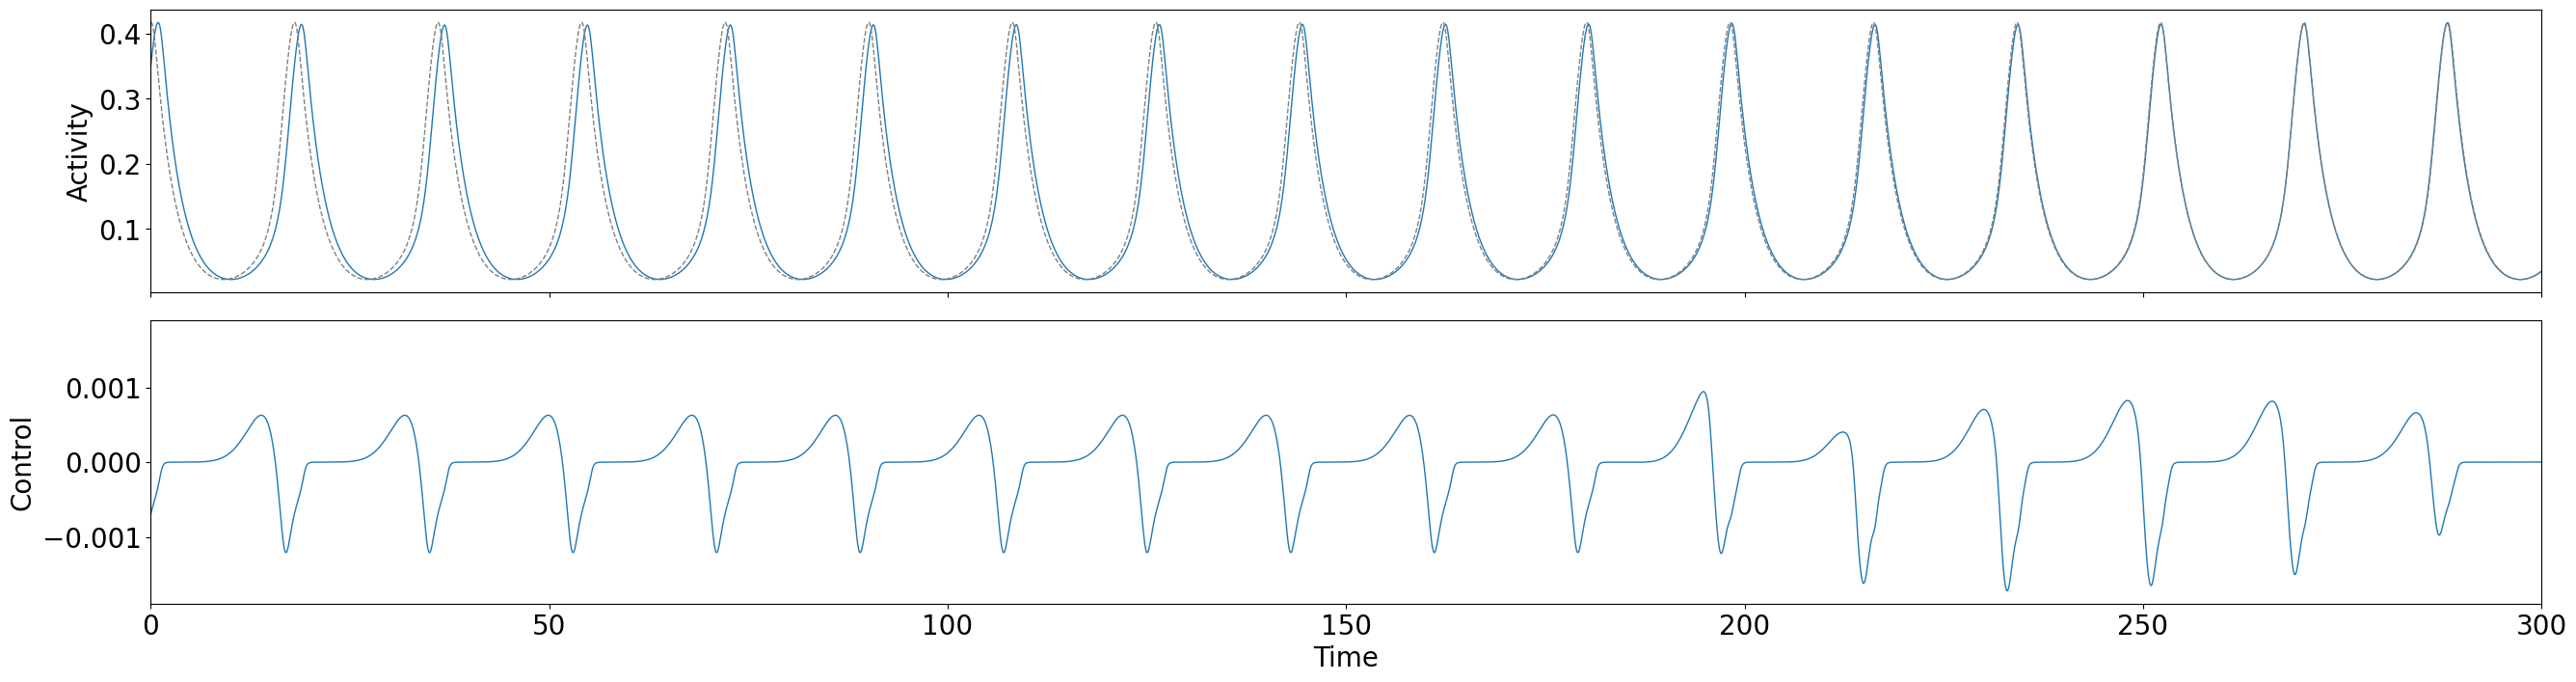

------------------------------------------------------------ phi =  0.6283185307179586
Optimal control with target time series
(1, 2, 3001)
Compute control for a deterministic system
Cost in iteration 0: 0.04611096585669916
Final cost : 0.04611096585669916
Compute control for a deterministic system
Cost in iteration 0: 0.0314099034255324
Cost in iteration 10: 0.0312833235634319
Final cost : 0.0312833235634319
Compute control for a deterministic system
Cost in iteration 0: 0.0312833235634319
Cost in iteration 10: 0.030041523361539365
Final cost : 0.030041523361539365
Compute control for a deterministic system
Cost in iteration 0: 0.030041523361539365
Cost in iteration 10: 0.019769699250299956
Final cost : 0.019769699250299956
Compute control for a deterministic system
Cost in iteration 0: 0.019769699250299956
Cost in iteration 10: 0.0006561069460501777
Final cost : 0.0006561069460501777
Compute control for a deterministic system
Cost in iteration 0: 0.0006561069460501777
Converged in it

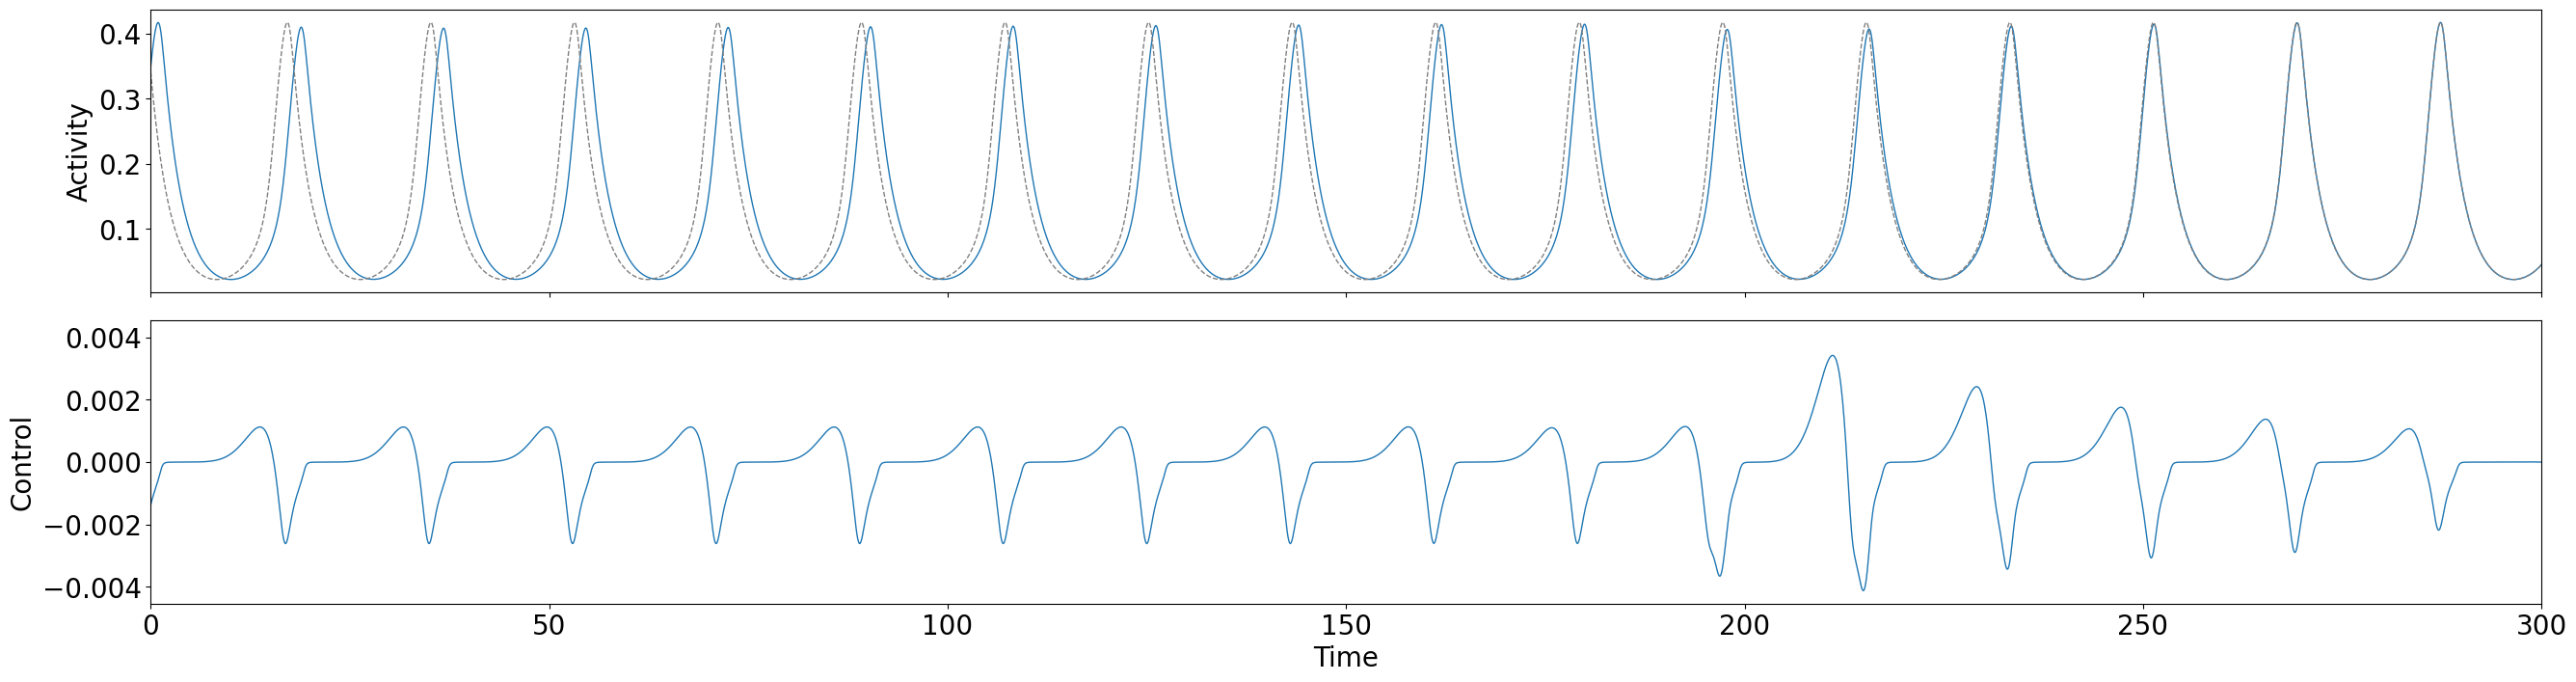

------------------------------------------------------------ phi =  0.9424777960769379
Optimal control with target time series
(1, 2, 3001)
Compute control for a deterministic system
Cost in iteration 0: 0.19264065023397114
Final cost : 0.19264065023397114
Compute control for a deterministic system
Cost in iteration 0: 0.06779876607243868
Cost in iteration 10: 0.06755698365276615
Final cost : 0.06755698365276615
Compute control for a deterministic system
Cost in iteration 0: 0.06755698365276615
Cost in iteration 10: 0.06518065566582348
Final cost : 0.06518065566582348
Compute control for a deterministic system
Cost in iteration 0: 0.06518065566582348
Cost in iteration 10: 0.04510478010271018
Final cost : 0.04510478010271018
Compute control for a deterministic system
Cost in iteration 0: 0.04510478010271018
Cost in iteration 10: 0.002877115200285745
Final cost : 0.002877115200285745
Compute control for a deterministic system
Cost in iteration 0: 0.002877115200285745
Converged in iterati

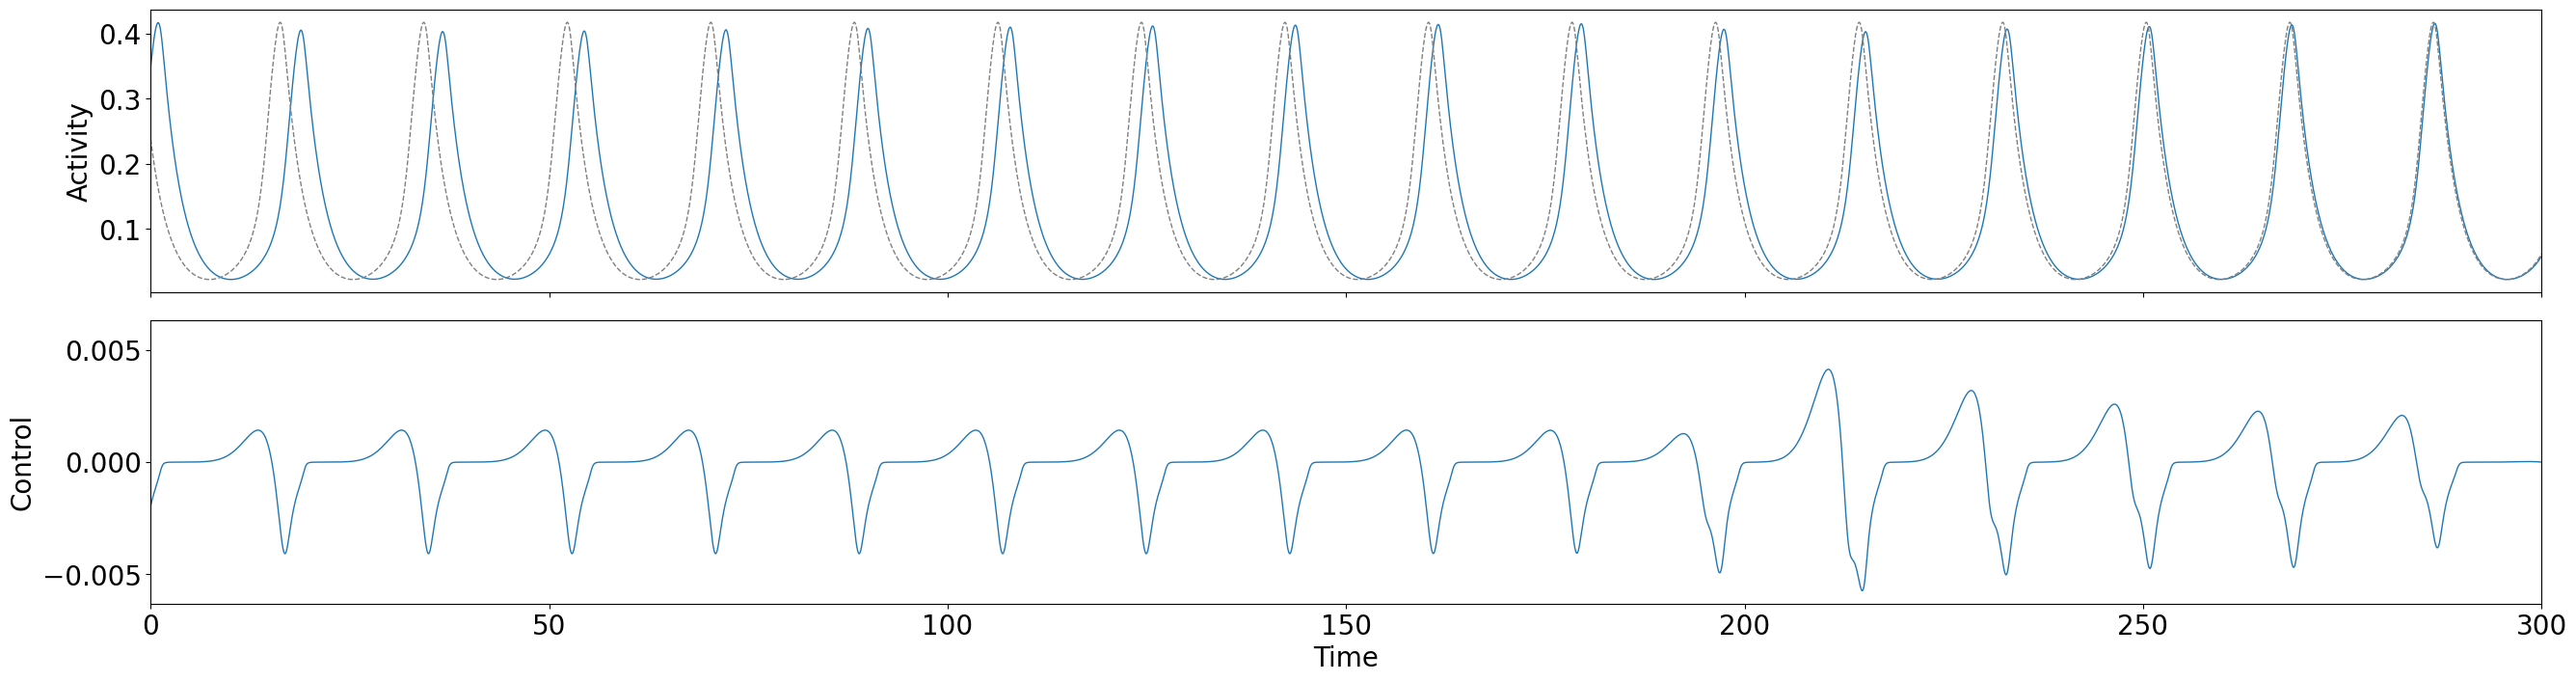

------------------------------------------------------------ phi =  1.2566370614359172
Optimal control with target time series
(1, 2, 3001)
Compute control for a deterministic system
Cost in iteration 0: 0.4097890547073928
Final cost : 0.4097890547073928
Compute control for a deterministic system
Cost in iteration 0: 0.10504931690822972
Cost in iteration 10: 0.10471098405782513
Final cost : 0.10471098405782513
Compute control for a deterministic system
Cost in iteration 0: 0.10471098405782513
Cost in iteration 10: 0.10137931990819174
Final cost : 0.10137931990819174
Compute control for a deterministic system
Cost in iteration 0: 0.10137931990819174
Cost in iteration 10: 0.0726352194386551
Final cost : 0.0726352194386551
Compute control for a deterministic system
Cost in iteration 0: 0.0726352194386551
Cost in iteration 10: 0.00683714836964421
Final cost : 0.00683714836964421
Compute control for a deterministic system
Cost in iteration 0: 0.00683714836964421
Converged in iteration 2 wit

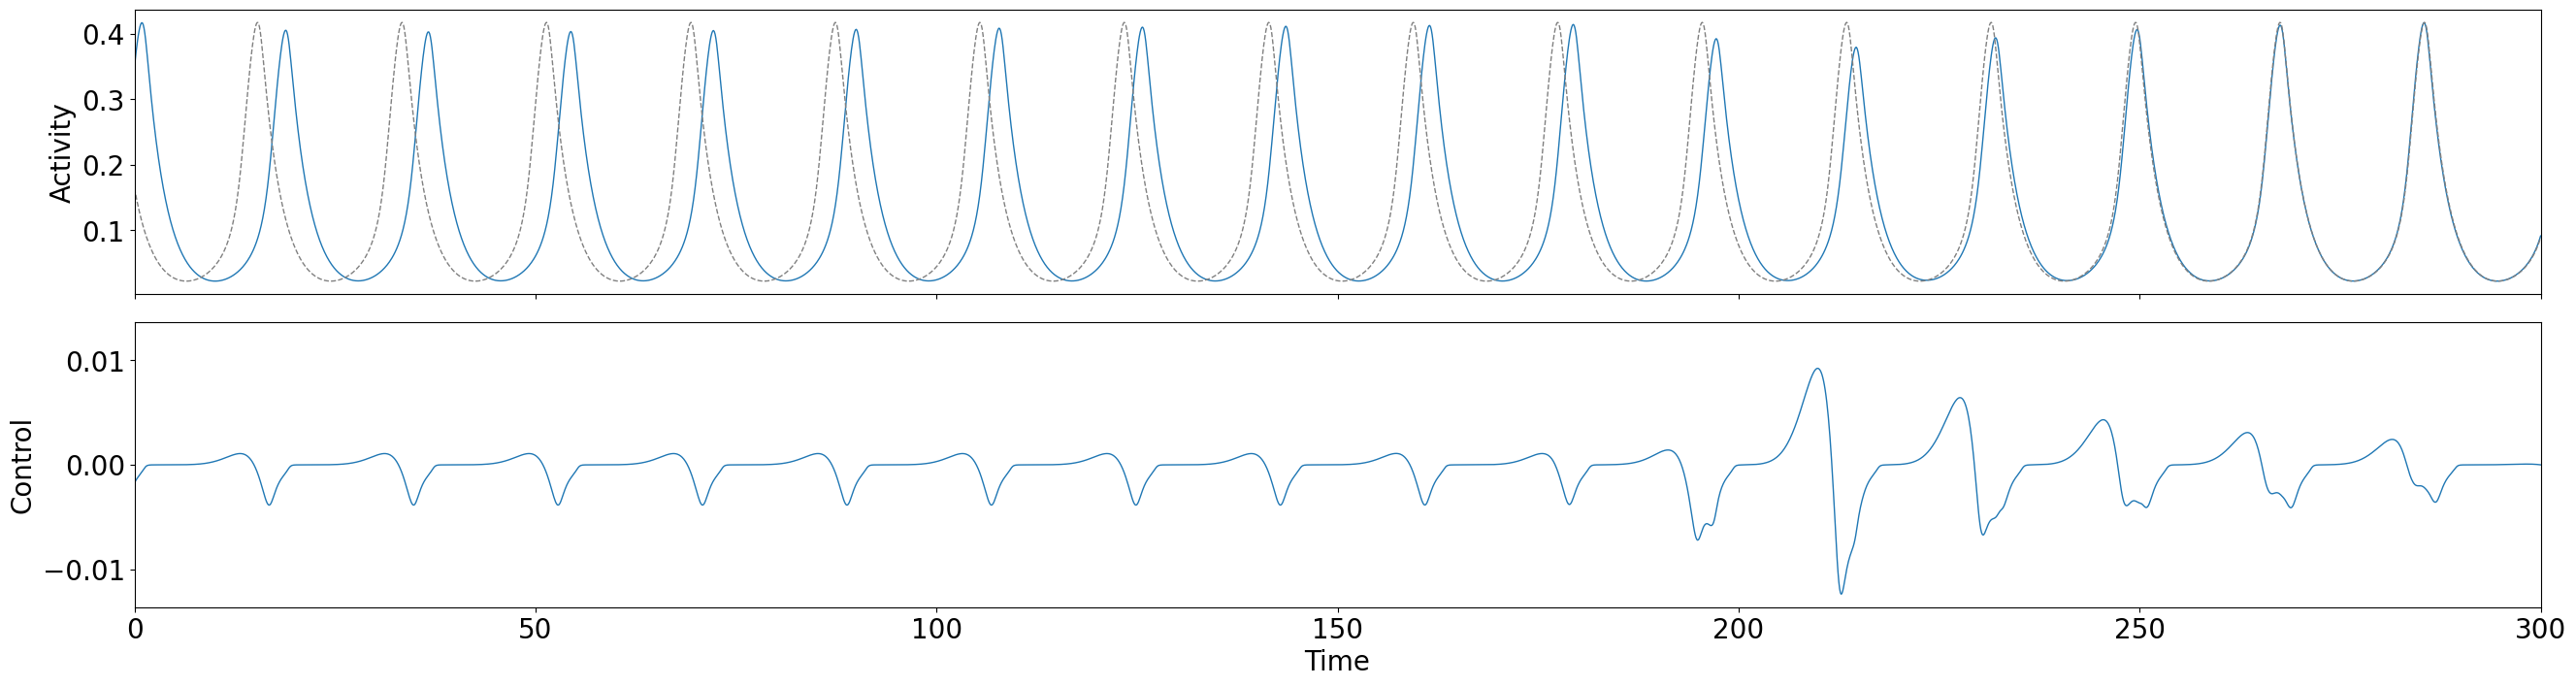

------------------------------------------------------------ phi =  1.5707963267948966


In [270]:
for pi, phi in enumerate(phi_shift):
    print("------------------------------------------------------------ phi = ", phi)

    if pi in [0, 19]: continue

    if pi == 5: break

    model = WCModel()

    model.params.exc_init = data["init_state"][0]
    model.params.inh_init = data["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data["coordinates"][0]
    model.params["inh_ext_baseline"] =  data["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, data["target"][pi], print_array=pr, cost_interval=(int(2*duration/(3*dt)), None), control_interval=control_int, cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_2"] = 1.

    #model_controlled.cost_interval = (6000, 10001)
    #model_controlled.control_interval = (0, 4000)

    if type(None) != type(data["control"][pi]):
        model_controlled.control = data["control"][pi].copy()
        print(model_controlled.control.shape)
        model_controlled.update_input()

    model_controlled.maximum_control_strength = max_cntrl

    # find initial signal
    model_controlled.optimize(0)

    for j in [0.1, 0.01]:
        model_controlled.weights["w_p"] = j #* (1. + 0.3*(np.random.rand() - 0.5))
        #model_controlled.control[0,0,6000:] = 0.
        #model_controlled.update_input()
        model_controlled.grad_method = 0

        for k in range(-6, 6, 1):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            get_results(data, pi, model_controlled)
            dump_data()

        model_controlled.grad_method = 1

        for k in range(-6, 6, 1):
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            get_results(data, pi, model_controlled)
            dump_data()
    
    plot_control(model_controlled.control, model_controlled.get_xs(), data["target"][pi], duration, dt, filename=None, title=None)

------------------------------------------------------------ phi =  0.0
------------------------------------------------------------ phi =  0.3141592653589793
------------------------------------------------------------ phi =  0.6283185307179586
------------------------------------------------------------ phi =  0.9424777960769379
------------------------------------------------------------ phi =  1.2566370614359172
Optimal control with target time series
Compute control for a deterministic system
Cost in iteration 0: 0.04349665491290469
Final cost : 0.04349665491290469
Compute control for a deterministic system
Cost in iteration 0: 0.06778322356462187
Converged in iteration 4 with cost 0.06778322356462185
Final cost : 0.06778322356462185
Compute control for a deterministic system
Cost in iteration 0: 0.06778322356462185
Converged in iteration 1 with cost 0.06778322356462185
Final cost : 0.06778322356462185
Compute control for a deterministic system
Cost in iteration 0: 0.0677832235646

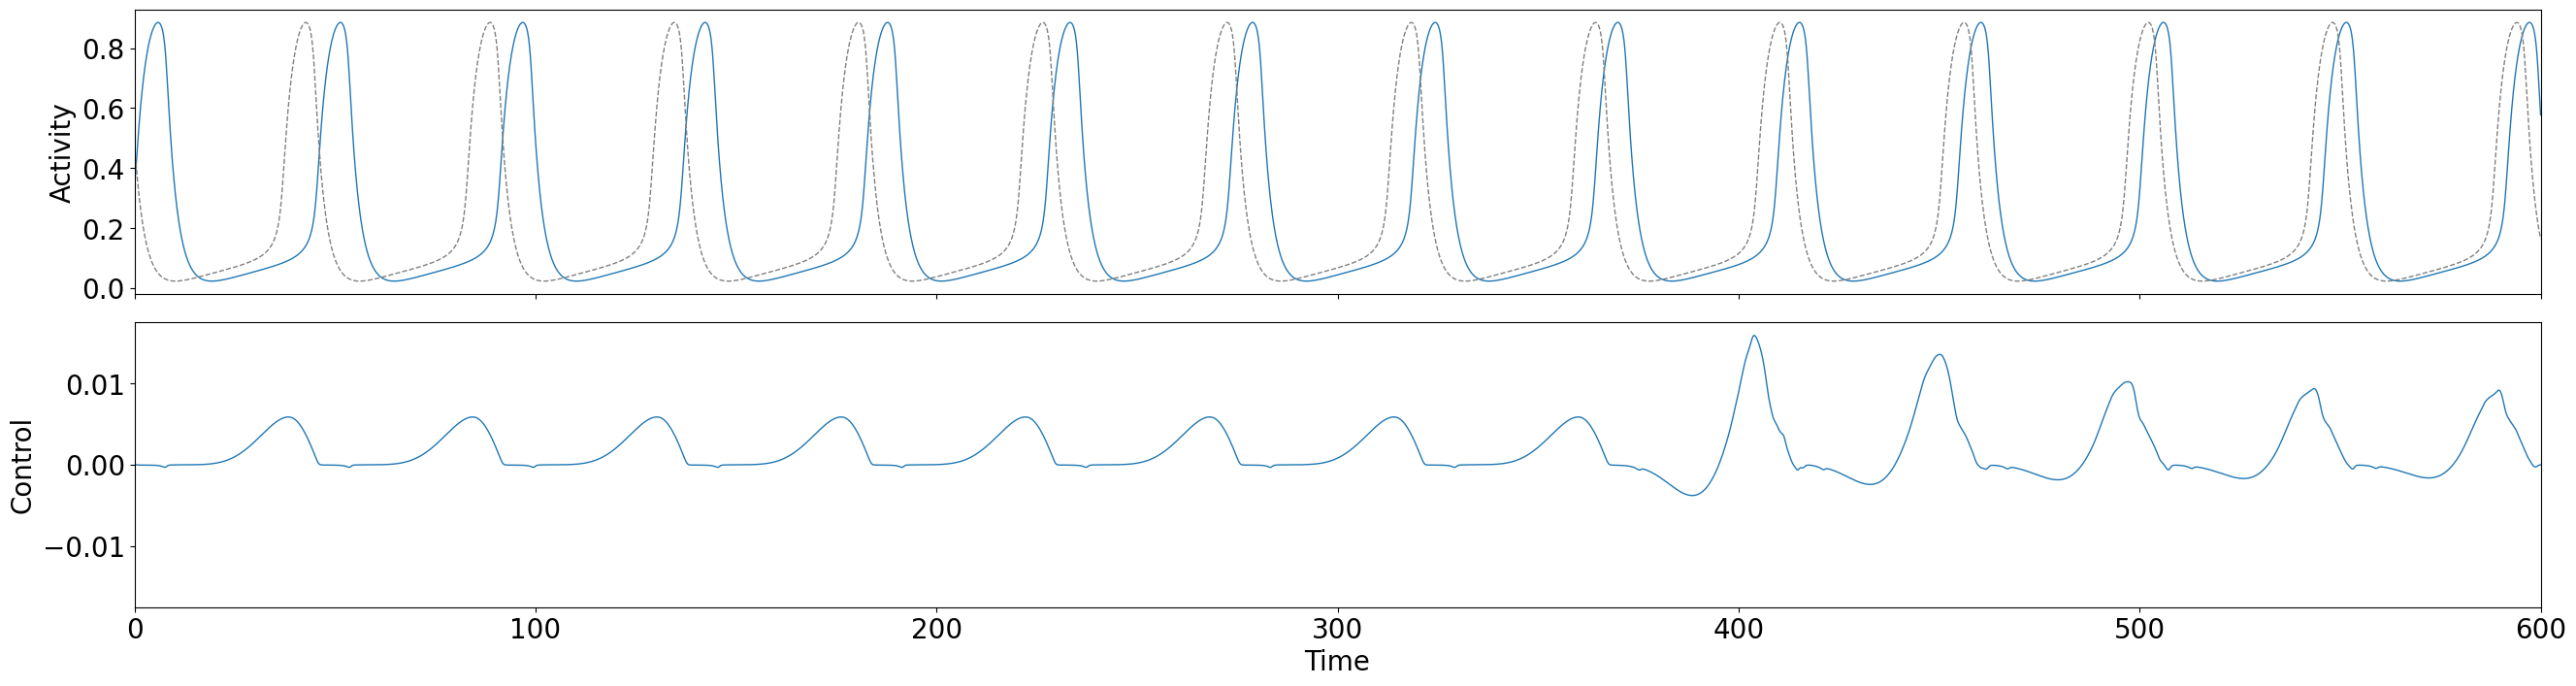

------------------------------------------------------------ phi =  1.5707963267948966
Optimal control with target time series
Compute control for a deterministic system
Cost in iteration 0: 0.06025044246307644
Final cost : 0.06025044246307644
Compute control for a deterministic system
Cost in iteration 0: 0.08302211691453937
Converged in iteration 1 with cost 0.08302211691453937
Final cost : 0.08302211691453937
Compute control for a deterministic system
Cost in iteration 0: 0.08302211691453937
Converged in iteration 1 with cost 0.08302211691453937
Final cost : 0.08302211691453937
Compute control for a deterministic system
Cost in iteration 0: 0.08302211691453937
Converged in iteration 1 with cost 0.08302211691453937
Final cost : 0.08302211691453937
Compute control for a deterministic system
Cost in iteration 0: 0.08302211691453937
Converged in iteration 1 with cost 0.08302211691453937
Final cost : 0.08302211691453937
Compute control for a deterministic system
Cost in iteration 0: 0.08

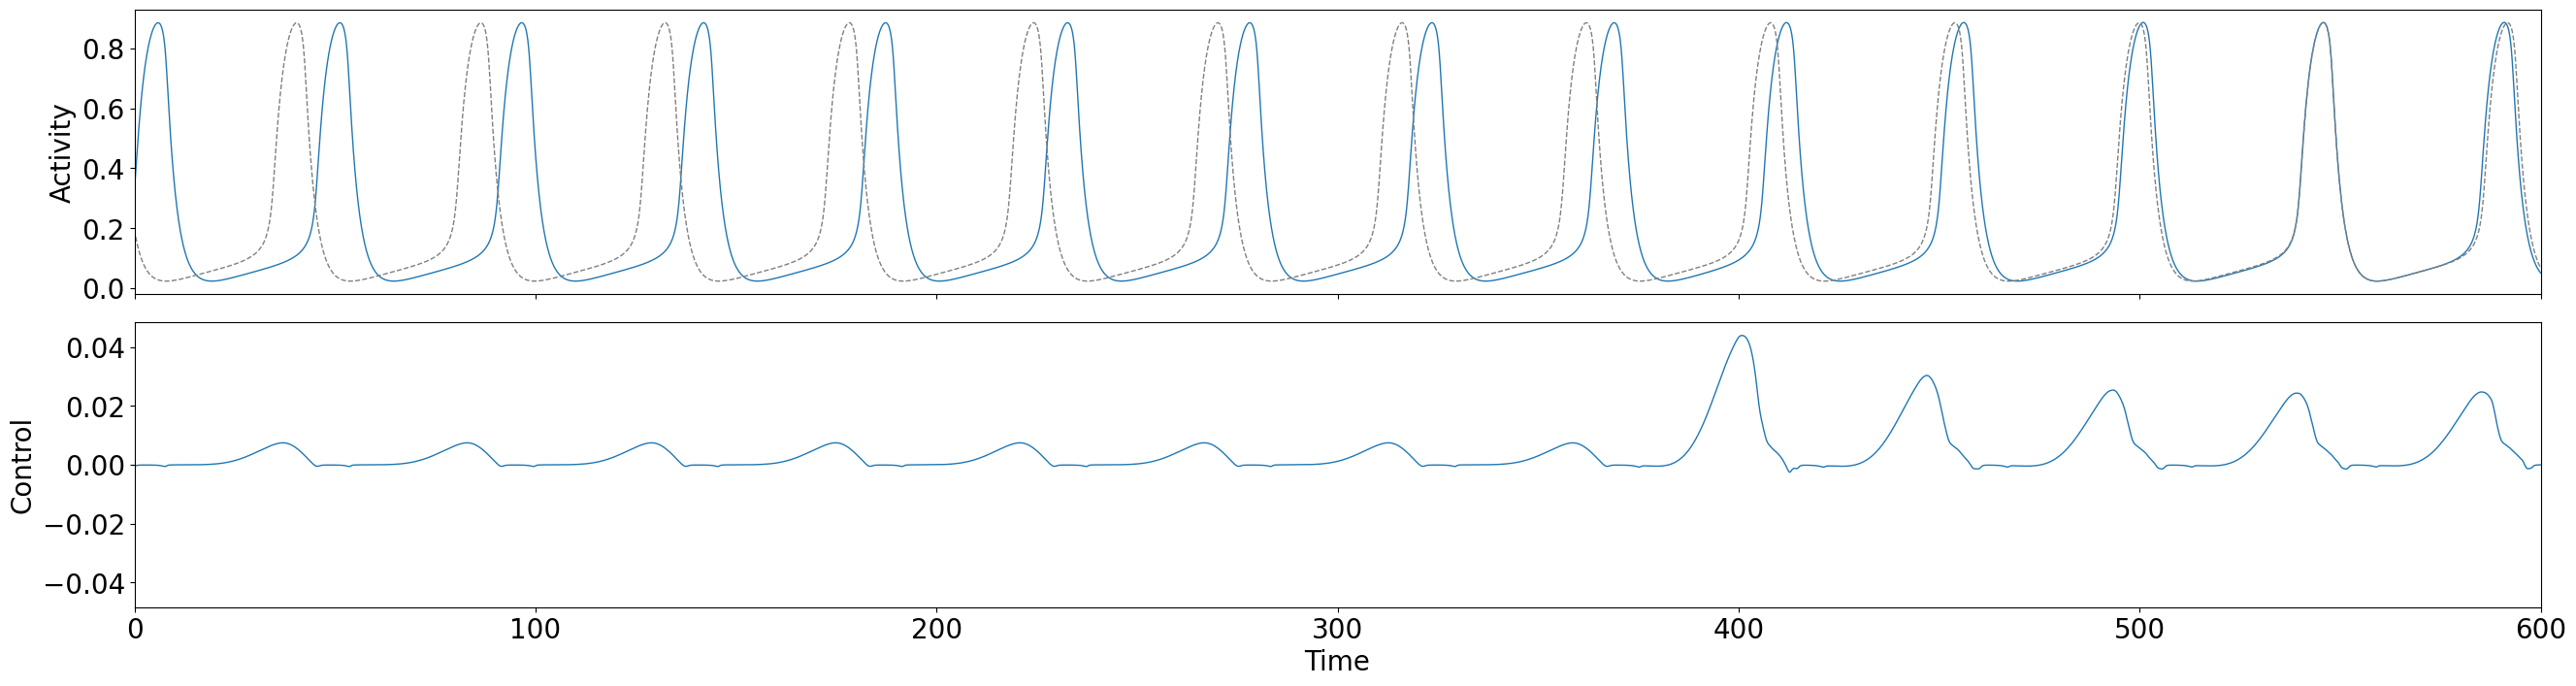

------------------------------------------------------------ phi =  1.8849555921538759
Optimal control with target time series
Compute control for a deterministic system
Cost in iteration 0: 0.09975414395310982
Final cost : 0.09975414395310982
Compute control for a deterministic system
Cost in iteration 0: 0.06895781337820828
Converged in iteration 1 with cost 0.06895781337820828
Final cost : 0.06895781337820828
Compute control for a deterministic system
Cost in iteration 0: 0.06895781337820828
Converged in iteration 1 with cost 0.06895781337820828
Final cost : 0.06895781337820828
Compute control for a deterministic system
Cost in iteration 0: 0.06895781337820828
Converged in iteration 1 with cost 0.06895781337820828
Final cost : 0.06895781337820828
Compute control for a deterministic system
Cost in iteration 0: 0.06895781337820828
Converged in iteration 1 with cost 0.06895781337820828
Final cost : 0.06895781337820828
Compute control for a deterministic system
Cost in iteration 0: 0.06

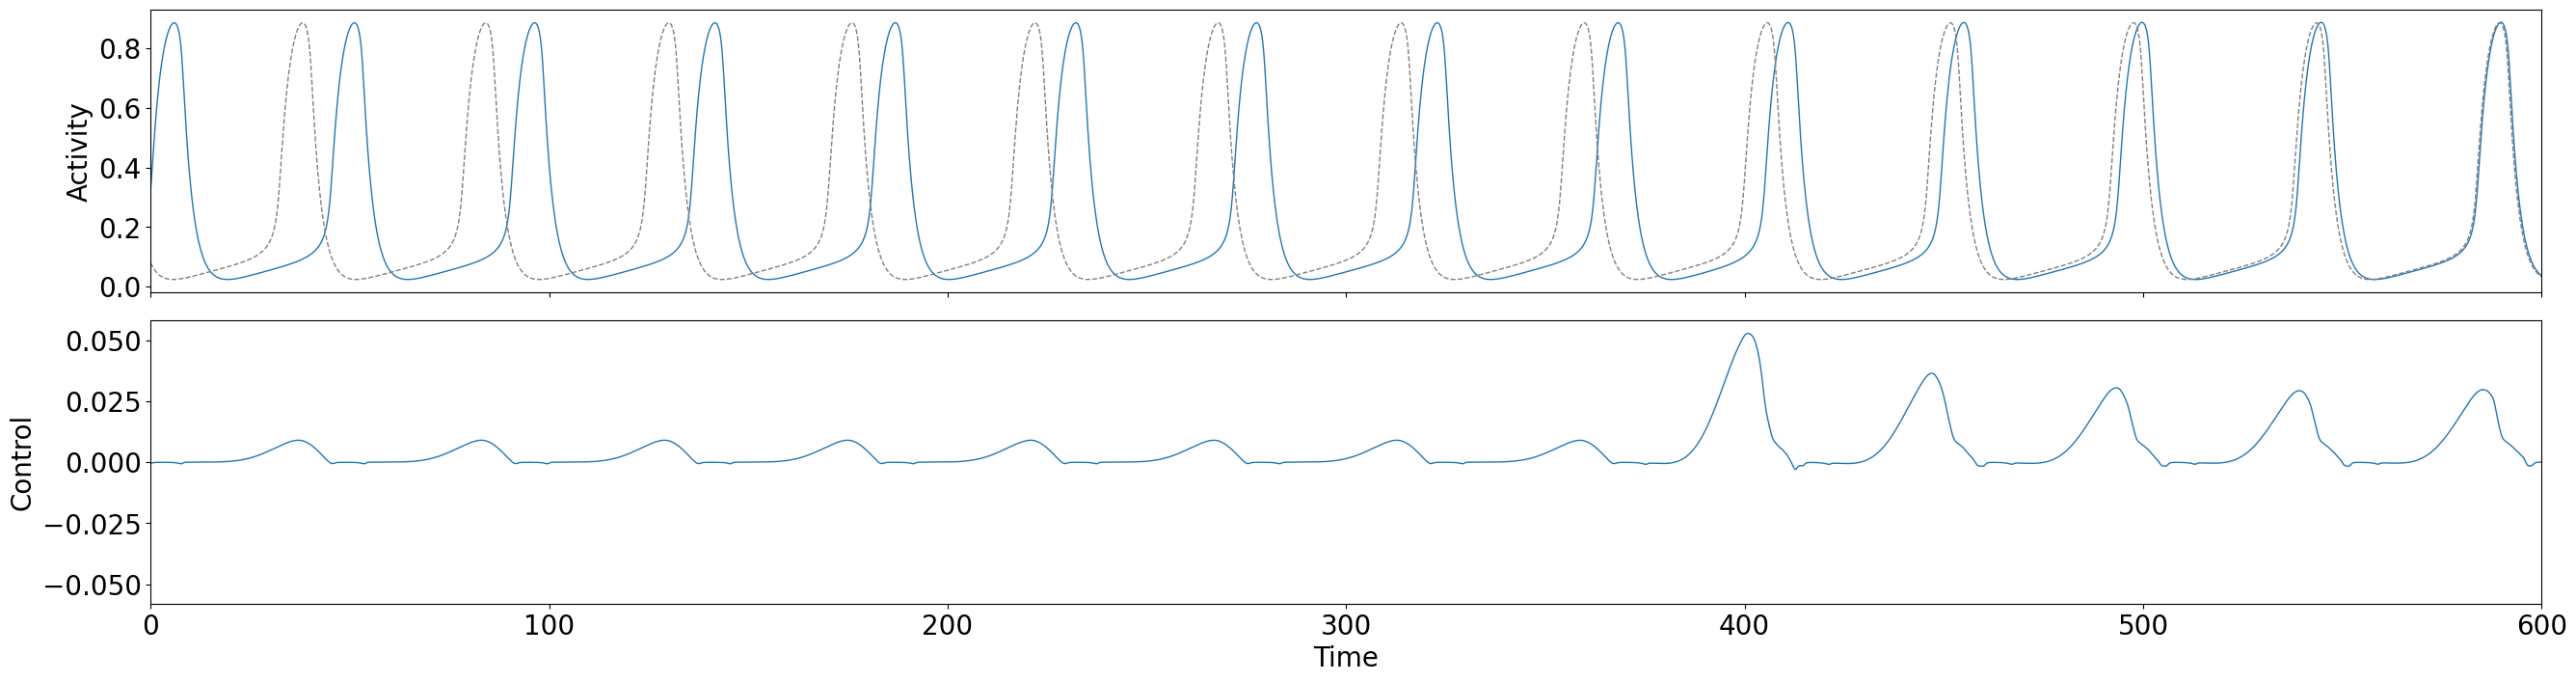

------------------------------------------------------------ phi =  2.199114857512855
------------------------------------------------------------ phi =  2.5132741228718345
------------------------------------------------------------ phi =  2.827433388230814
------------------------------------------------------------ phi =  3.141592653589793
------------------------------------------------------------ phi =  3.4557519189487724
------------------------------------------------------------ phi =  3.7699111843077517
------------------------------------------------------------ phi =  4.084070449666731
------------------------------------------------------------ phi =  4.39822971502571
------------------------------------------------------------ phi =  4.71238898038469
------------------------------------------------------------ phi =  5.026548245743669
------------------------------------------------------------ phi =  5.340707511102648
-----------------------------------------------------

In [188]:
for pi, phi in enumerate(phi_shift):
    print("------------------------------------------------------------ phi = ", phi)

    if pi in [0]: continue

    if pi not in [4, 5, 6]: continue

    model = WCModel()

    model.params.exc_init = data["init_state"][0]
    model.params.inh_init = data["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data["coordinates"][0]
    model.params["inh_ext_baseline"] =  data["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, data["target"][pi], print_array=pr, cost_interval=(4000, None), control_interval=control_int, cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_2"] = 1.
    model_controlled.weights["w_p"] = 1e-2

    if type(None) != type(data["control"][pi]):
        model_controlled.control = data["control"][pi].copy()
        model_controlled.update_input()

    model_controlled.maximum_control_strength = max_cntrl
    model_controlled.optimize(0)
    cost0 = model_controlled.compute_total_cost()

    model_controlled.control = data["control"][pi-1].copy() * 1.2
    model_controlled.update_input()

    for k in range(-6, 6, 1):
        model_controlled.zero_step_encountered = False
        model_controlled.step = 10.**(k)
        model_controlled.optimize(it)

    model_controlled.grad_method = 1

    for k in range(-6, 6, 1):
        model_controlled.zero_step_encountered = False
        model_controlled.step = 10.**(k)
        model_controlled.optimize(it)

    cost1 = model_controlled.compute_total_cost()
    if cost1 < cost0:
        print("IMPROVED")
        get_results(data, pi, model_controlled)
        dump_data()
    
    plot_control(model_controlled.control, model_controlled.get_xs(), data["target"][pi], duration, dt, filename=None, title=None)